Running throughput vs capacity experiment...
Beta = 0.55, estimated R0 ~ 2.68
------------------------------------------------------------
  Running: capacity=30, η=0.05
  Running: capacity=30, η=0.2
  Running: capacity=30, η=0.5
  Running: capacity=30, η=2.0
  Running: capacity=30, η=5.0
  Running: capacity=30, η=10.0
  Running: capacity=75, η=0.05
  Running: capacity=75, η=0.2
  Running: capacity=75, η=0.5
  Running: capacity=75, η=2.0
  Running: capacity=75, η=5.0
  Running: capacity=75, η=10.0
  Running: capacity=150, η=0.05
  Running: capacity=150, η=0.2
  Running: capacity=150, η=0.5
  Running: capacity=150, η=2.0
  Running: capacity=150, η=5.0
  Running: capacity=150, η=10.0
  Running: capacity=300, η=0.05
  Running: capacity=300, η=0.2
  Running: capacity=300, η=0.5
  Running: capacity=300, η=2.0
  Running: capacity=300, η=5.0
  Running: capacity=300, η=10.0
  Running: capacity=450, η=0.05
  Running: capacity=450, η=0.2
  Running: capacity=450, η=0.5
  Running: capacity=450, η=

/var/folders/8_/cxjvz9c51291hfp8mwjm_wmh0000gn/T/ipykernel_48526/375487697.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: ../paper/figures/throughput_vs_capacity.pdf
  Saved: ../paper/figures/throughput_dynamics_supplementary.pdf


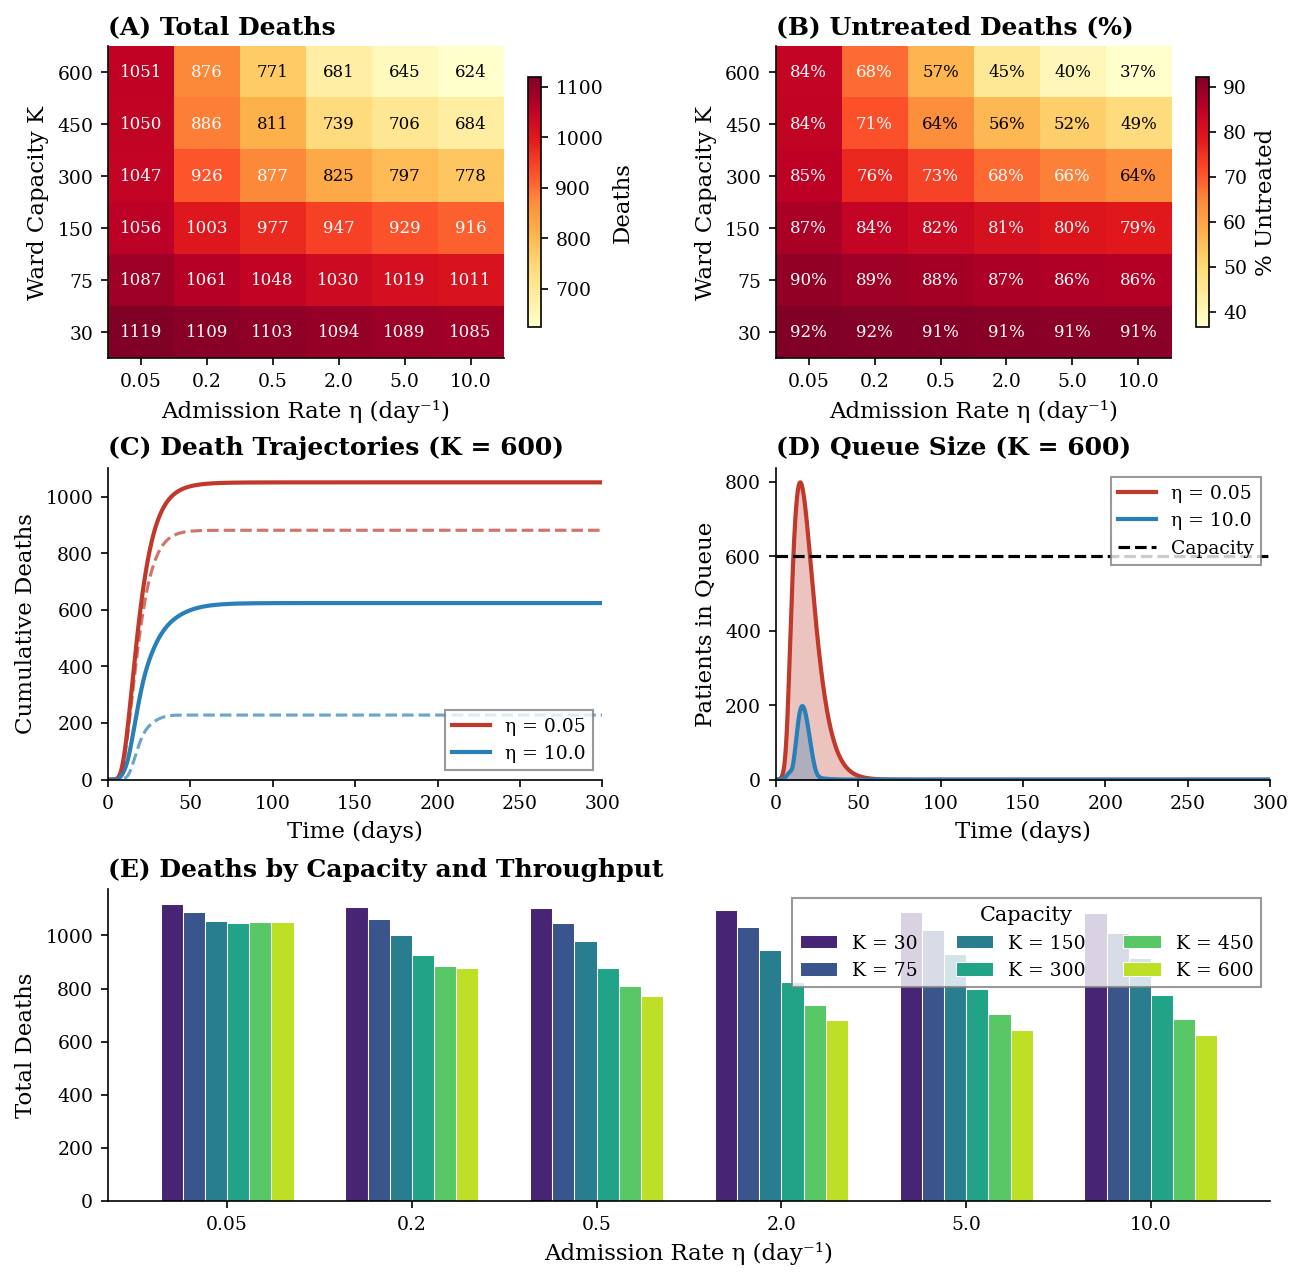

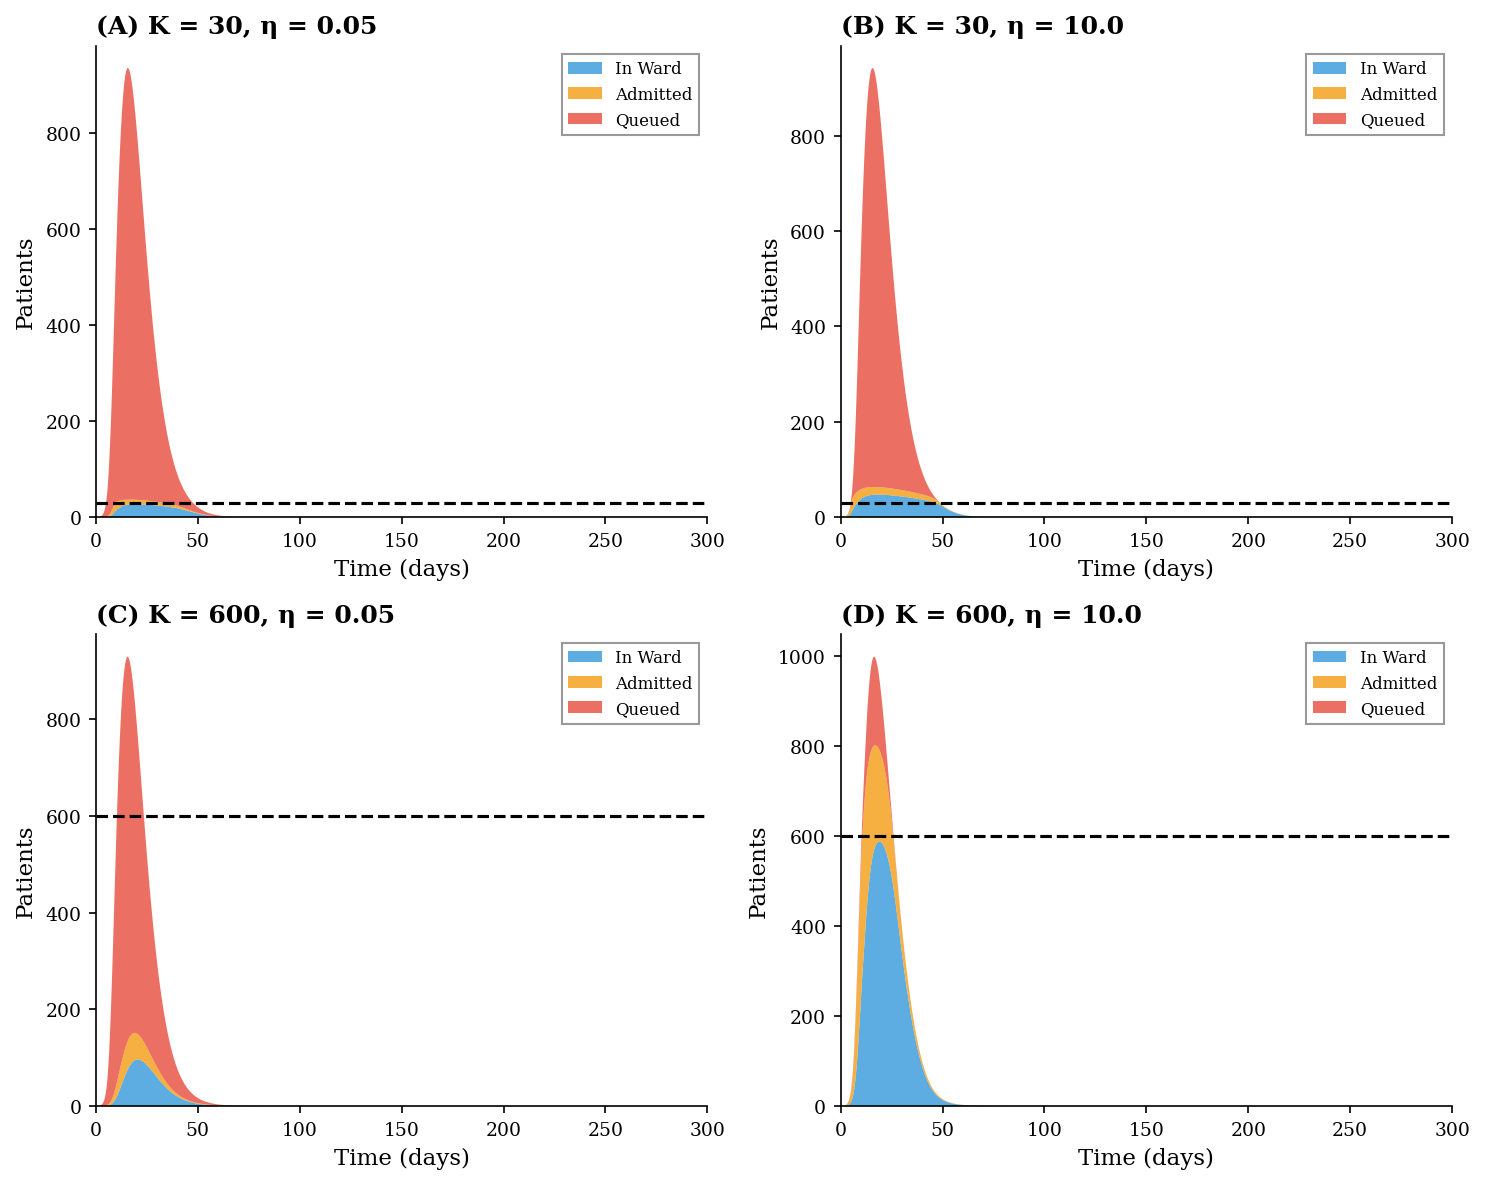


Experiment complete!


In [ ]:
"""
Experiment: The Hidden Mortality of Waiting Times

This experiment demonstrates that hospital throughput (admission rate η) is as 
critical as bed capacity (K) in determining epidemic mortality. It shows how 
queue accumulation leads to "untreated" deaths even when total bed capacity 
appears sufficient.

Generates Figure for Section: "The Hidden Mortality of Waiting Times"
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import sys
import os


from hospital_model import simulate_model
from hospital_model.scenarios import (
    AGE_PARAMS_DEFAULT, 
    CONTACT_MATRIX_DEFAULT, 
    AGE_POPS_DEFAULT,
    DEFAULT_CAPACITY_PARAMS,
)

# Set publication-quality defaults
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
})


def calculate_r0(beta, gamma_I, sigma, age_params):
    """Approximate R0 for the model."""
    avg_gamma = np.mean([p['gamma_I'] for p in age_params])
    avg_sigma = np.mean([p['sigma'] for p in age_params])
    avg_mu = np.mean([p['mu_I'] for p in age_params])
    return beta / (avg_gamma + avg_sigma + avg_mu)


def run_throughput_capacity_experiment():
    """
    Run experiment comparing effects of capacity vs throughput on mortality.
    """
    beta_high = 0.55
    Tmax = 300
    time_step = 0.25
    
    capacity_levels = [30, 75, 150, 300, 450, 600]
    eta_values = [0.05, 0.2, 0.5, 2.0, 5.0, 10.0]
    
    results_grid = {}
    
    print("Running throughput vs capacity experiment...")
    print(f"Beta = {beta_high}, estimated R0 ~ {calculate_r0(beta_high, 0.1, 0.1, AGE_PARAMS_DEFAULT):.2f}")
    print("-" * 60)
    
    for capacity in capacity_levels:
        results_grid[capacity] = {}
        for eta in eta_values:
            print(f"  Running: capacity={capacity}, η={eta}")
            
            modified_age_params = []
            for params in AGE_PARAMS_DEFAULT:
                modified = params.copy()
                modified['eta'] = eta
                if 'mu_X_untreated' in modified:
                    modified['mu_X_untreated'] = modified.get('mu_X', 0.01) * 5
                else:
                    modified['mu_X_untreated'] = 0.05
                modified['mu_X'] = 0.01
                modified_age_params.append(modified)
            
            results = simulate_model(
                beta_base=beta_high,
                age_params=modified_age_params,
                contact_matrix=CONTACT_MATRIX_DEFAULT,
                age_pops=AGE_POPS_DEFAULT,
                sim_config={
                    'Tmax': Tmax,
                    'time_step': time_step,
                    'theta_X': 0.5,
                    'theta_H': 0.1,
                },
                capacity_config={
                    'ward_capacity': capacity,
                    'icu_capacity': max(capacity // 5, 5),
                    'hill_coef_ward': 9,
                    'hill_coef_icu': 9,
                },
                track_differential_mortality=True,
            )
            
            results_grid[capacity][eta] = results
    
    return results_grid, capacity_levels, eta_values, Tmax


def create_main_figure(results_grid, capacity_levels, eta_values, Tmax):
    """
    Create clean publication-quality figure.
    """
    
    fig = plt.figure(figsize=(10, 10))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1], hspace=0.35, wspace=0.35)
    
    # Prepare data matrices
    total_deaths = np.zeros((len(capacity_levels), len(eta_values)))
    untreated_fraction = np.zeros((len(capacity_levels), len(eta_values)))
    
    for i, capacity in enumerate(capacity_levels):
        for j, eta in enumerate(eta_values):
            results = results_grid[capacity][eta]
            total_deaths[i, j] = results['D_total'][-1]
            d_treated = results['D_treated_total'][-1]
            d_untreated = results['D_untreated_total'][-1]
            if (d_treated + d_untreated) > 0:
                untreated_fraction[i, j] = d_untreated / (d_treated + d_untreated)
    
    # ========================================
    # Panel A: Total Deaths Heatmap
    # ========================================
    ax1 = fig.add_subplot(gs[0, 0])
    
    im1 = ax1.imshow(total_deaths, cmap='YlOrRd', aspect='auto', origin='lower')
    ax1.set_xticks(range(len(eta_values)))
    ax1.set_xticklabels([f'{e}' for e in eta_values])
    ax1.set_yticks(range(len(capacity_levels)))
    ax1.set_yticklabels([f'{c}' for c in capacity_levels])
    ax1.set_xlabel('Admission Rate η (day⁻¹)')
    ax1.set_ylabel('Ward Capacity K')
    ax1.set_title('(A) Total Deaths', fontweight='bold', loc='left')
    
    for i in range(len(capacity_levels)):
        for j in range(len(eta_values)):
            val = total_deaths[i, j]
            norm_val = (val - total_deaths.min()) / (total_deaths.max() - total_deaths.min())
            text_color = 'white' if norm_val > 0.5 else 'black'
            ax1.text(j, i, f'{val:.0f}', ha='center', va='center', 
                    fontsize=8, color=text_color)
    
    cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
    cbar1.set_label('Deaths')
    
    # ========================================
    # Panel B: Untreated Deaths Fraction Heatmap
    # ========================================
    ax2 = fig.add_subplot(gs[0, 1])
    
    im2 = ax2.imshow(untreated_fraction * 100, cmap='YlOrRd', aspect='auto', origin='lower')
    ax2.set_xticks(range(len(eta_values)))
    ax2.set_xticklabels([f'{e}' for e in eta_values])
    ax2.set_yticks(range(len(capacity_levels)))
    ax2.set_yticklabels([f'{c}' for c in capacity_levels])
    ax2.set_xlabel('Admission Rate η (day⁻¹)')
    ax2.set_ylabel('Ward Capacity K')
    ax2.set_title('(B) Untreated Deaths (%)', fontweight='bold', loc='left')
    
    for i in range(len(capacity_levels)):
        for j in range(len(eta_values)):
            pct = untreated_fraction[i, j] * 100
            text_color = 'white' if pct > 65 else 'black'
            ax2.text(j, i, f'{pct:.0f}%', ha='center', va='center',
                    fontsize=8, color=text_color)
    
    cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
    cbar2.set_label('% Untreated')
    
    # ========================================
    # Panel C: Time Series - Deaths Comparison
    # ========================================
    ax3 = fig.add_subplot(gs[1, 0])
    
    high_cap = capacity_levels[-1]
    low_eta = eta_values[0]
    high_eta = eta_values[-1]
    
    results_low_eta = results_grid[high_cap][low_eta]
    results_high_eta = results_grid[high_cap][high_eta]
    
    times = results_low_eta['times']
    
    ax3.plot(times, results_low_eta['D_total'], color='#c0392b', linewidth=2, 
             label=f'η = {low_eta}', linestyle='-')
    ax3.plot(times, results_high_eta['D_total'], color='#2980b9', linewidth=2,
             label=f'η = {high_eta}', linestyle='-')
    ax3.plot(times, results_low_eta['D_untreated_total'], color='#c0392b', 
             linewidth=1.5, linestyle='--', alpha=0.7)
    ax3.plot(times, results_high_eta['D_untreated_total'], color='#2980b9', 
             linewidth=1.5, linestyle='--', alpha=0.7)
    
    ax3.set_xlabel('Time (days)')
    ax3.set_ylabel('Cumulative Deaths')
    ax3.set_title(f'(C) Death Trajectories (K = {high_cap})', fontweight='bold', loc='left')
    ax3.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='gray')
    ax3.set_xlim(0, Tmax)
    ax3.set_ylim(0, None)
    
    # ========================================
    # Panel D: Queue Dynamics
    # ========================================
    ax4 = fig.add_subplot(gs[1, 1])
    
    X_queued_low = np.sum([results_low_eta['X_queued'][a] for a in range(len(results_low_eta['X_queued']))], axis=0)
    X_queued_high = np.sum([results_high_eta['X_queued'][a] for a in range(len(results_high_eta['X_queued']))], axis=0)
    
    ax4.fill_between(times, 0, X_queued_low, alpha=0.3, color='#c0392b')
    ax4.fill_between(times, 0, X_queued_high, alpha=0.3, color='#2980b9')
    ax4.plot(times, X_queued_low, color='#c0392b', linewidth=2, label=f'η = {low_eta}')
    ax4.plot(times, X_queued_high, color='#2980b9', linewidth=2, label=f'η = {high_eta}')
    
    ax4.axhline(y=high_cap, color='black', linestyle='--', linewidth=1.5, label='Capacity')
    
    ax4.set_xlabel('Time (days)')
    ax4.set_ylabel('Patients in Queue')
    ax4.set_title(f'(D) Queue Size (K = {high_cap})', fontweight='bold', loc='left')
    ax4.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
    ax4.set_xlim(0, Tmax)
    ax4.set_ylim(0, None)
    
    # ========================================
    # Panel E: Bar Chart - Capacity vs Throughput
    # ========================================
    ax5 = fig.add_subplot(gs[2, :])
    
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(capacity_levels)))
    
    x_positions = np.arange(len(eta_values))
    bar_width = 0.12
    
    for i, capacity in enumerate(capacity_levels):
        deaths_at_capacity = [results_grid[capacity][eta]['D_total'][-1] for eta in eta_values]
        offset = (i - len(capacity_levels)/2 + 0.5) * bar_width
        ax5.bar(x_positions + offset, deaths_at_capacity, bar_width, 
                label=f'K = {capacity}', color=colors[i], edgecolor='white', linewidth=0.5)
    
    ax5.set_xticks(x_positions)
    ax5.set_xticklabels([f'{e}' for e in eta_values])
    ax5.set_xlabel('Admission Rate η (day⁻¹)')
    ax5.set_ylabel('Total Deaths')
    ax5.set_title('(E) Deaths by Capacity and Throughput', fontweight='bold', loc='left')
    ax5.legend(title='Capacity', loc='upper right', ncol=3, frameon=True, 
               fancybox=False, edgecolor='gray')
    ax5.set_ylim(0, None)
    
    plt.tight_layout()
    
    return fig


def create_supplementary_figure(results_grid, capacity_levels, eta_values, Tmax):
    """
    Create clean supplementary figure showing patient flow dynamics.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    scenarios = [
        (capacity_levels[0], eta_values[0], f'K = {capacity_levels[0]}, η = {eta_values[0]}'),
        (capacity_levels[0], eta_values[-1], f'K = {capacity_levels[0]}, η = {eta_values[-1]}'),
        (capacity_levels[-1], eta_values[0], f'K = {capacity_levels[-1]}, η = {eta_values[0]}'),
        (capacity_levels[-1], eta_values[-1], f'K = {capacity_levels[-1]}, η = {eta_values[-1]}'),
    ]
    
    panel_labels = ['(A)', '(B)', '(C)', '(D)']
    
    for ax, (cap, eta, label), panel in zip(axes.flat, scenarios, panel_labels):
        results = results_grid[cap][eta]
        times = results['times']
        
        X_queued_total = np.sum([results['X_queued'][a] for a in range(len(results['X_queued']))], axis=0)
        X_admitted_total = np.sum([results['X_admitted'][a] for a in range(len(results['X_admitted']))], axis=0)
        H_ward_total = results['H_ward_total']
        
        ax.stackplot(times, 
                     H_ward_total, X_admitted_total, X_queued_total,
                     labels=['In Ward', 'Admitted', 'Queued'],
                     colors=['#3498db', '#f39c12', '#e74c3c'],
                     alpha=0.8)
        
        ax.axhline(y=cap, color='black', linestyle='--', linewidth=1.5)
        
        ax.set_xlabel('Time (days)')
        ax.set_ylabel('Patients')
        ax.set_title(f'{panel} {label}', fontweight='bold', loc='left')
        ax.set_xlim(0, Tmax)
        ax.legend(loc='upper right', fontsize=8, frameon=True, fancybox=False, edgecolor='gray')
    
    plt.tight_layout()
    return fig


def print_summary_statistics(results_grid, capacity_levels, eta_values):
    """Print summary statistics for the paper."""
    print("\n" + "="*70)
    print("SUMMARY STATISTICS FOR PAPER")
    print("="*70)
    
    min_deaths = float('inf')
    max_deaths = 0
    min_case = None
    max_case = None
    
    for cap in capacity_levels:
        for eta in eta_values:
            deaths = results_grid[cap][eta]['D_total'][-1]
            if deaths < min_deaths:
                min_deaths = deaths
                min_case = (cap, eta)
            if deaths > max_deaths:
                max_deaths = deaths
                max_case = (cap, eta)
    
    print(f"\nBest case: K={min_case[0]}, η={min_case[1]} → {min_deaths:.0f} deaths")
    print(f"Worst case: K={max_case[0]}, η={max_case[1]} → {max_deaths:.0f} deaths")
    print(f"Mortality difference: {(max_deaths - min_deaths):.0f} deaths ({(max_deaths/min_deaths - 1)*100:.1f}% increase)")
    
    high_cap, low_eta = capacity_levels[-1], eta_values[0]
    low_cap, high_eta = capacity_levels[0], eta_values[-1]
    
    deaths_hc_le = results_grid[high_cap][low_eta]['D_total'][-1]
    deaths_lc_he = results_grid[low_cap][high_eta]['D_total'][-1]
    
    print(f"\nKEY COMPARISON:")
    print(f"  High capacity (K={high_cap}), slow throughput (η={low_eta}): {deaths_hc_le:.0f} deaths")
    print(f"  Low capacity (K={low_cap}), fast throughput (η={high_eta}): {deaths_lc_he:.0f} deaths")
    
    print(f"\nUNTREATED DEATH ANALYSIS:")
    for cap in [capacity_levels[0], capacity_levels[-1]]:
        print(f"\n  Capacity K={cap}:")
        for eta in eta_values:
            results = results_grid[cap][eta]
            d_treated = results['D_treated_total'][-1]
            d_untreated = results['D_untreated_total'][-1]
            total = d_treated + d_untreated
            pct = (d_untreated / total * 100) if total > 0 else 0
            print(f"    η={eta}: {d_untreated:.0f}/{total:.0f} untreated ({pct:.1f}%)")
    
    print("\n" + "="*70)


def main():
    """Run the complete experiment and generate figures."""
    
    results_grid, capacity_levels, eta_values, Tmax = run_throughput_capacity_experiment()
    
    print_summary_statistics(results_grid, capacity_levels, eta_values)
    
    print("\nGenerating figures...")
    
    fig_main = create_main_figure(results_grid, capacity_levels, eta_values, Tmax)
    
    output_dir = '../paper/figures'
    os.makedirs(output_dir, exist_ok=True)
    
    fig_main.savefig(os.path.join(output_dir, 'throughput_vs_capacity.pdf'), 
                     bbox_inches='tight', dpi=300)
    fig_main.savefig(os.path.join(output_dir, 'throughput_vs_capacity.png'), 
                     bbox_inches='tight', dpi=300)
    print(f"  Saved: {output_dir}/throughput_vs_capacity.pdf")
    
    fig_supp = create_supplementary_figure(results_grid, capacity_levels, eta_values, Tmax)
    fig_supp.savefig(os.path.join(output_dir, 'throughput_dynamics_supplementary.pdf'),
                     bbox_inches='tight', dpi=300)
    fig_supp.savefig(os.path.join(output_dir, 'throughput_dynamics_supplementary.png'),
                     bbox_inches='tight', dpi=300)
    print(f"  Saved: {output_dir}/throughput_dynamics_supplementary.pdf")
    
    plt.show()
    
    print("\nExperiment complete!")
    return results_grid


results = main()